#### 생선의 길이를 사용해 무게를 예측

In [2]:
import numpy as np

In [3]:
fish_length = np.array(
    [8.4, 13.7, 15.0, 16.2, 17.4, 18.0, 18.7, 19.0, 19.6, 20.0, 
     21.0, 21.0, 21.0, 21.3, 22.0, 22.0, 22.0, 22.0, 22.0, 22.5, 
     22.5, 22.7, 23.0, 23.5, 24.0, 24.0, 24.6, 25.0, 25.6, 26.5, 
     27.3, 27.5, 27.5, 27.5, 28.0, 28.7, 30.0, 32.8, 34.5, 35.0, 
     36.5, 36.0, 37.0, 37.0, 39.0, 39.0, 39.0, 40.0, 40.0, 40.0, 
     40.0, 42.0, 43.0, 43.0, 43.5, 44.0]
     )
fish_weight = np.array(
    [5.9, 32.0, 40.0, 51.5, 70.0, 100.0, 78.0, 80.0, 85.0, 85.0, 
     110.0, 115.0, 125.0, 130.0, 120.0, 120.0, 130.0, 135.0, 110.0, 
     130.0, 150.0, 145.0, 150.0, 170.0, 225.0, 145.0, 188.0, 180.0, 
     197.0, 218.0, 300.0, 260.0, 265.0, 250.0, 250.0, 300.0, 320.0, 
     514.0, 556.0, 840.0, 685.0, 700.0, 700.0, 690.0, 900.0, 650.0, 
     820.0, 850.0, 900.0, 1015.0, 820.0, 1100.0, 1000.0, 1100.0, 
     1000.0, 1000.0]
     )

#### 길이와 무게를 산포도로 표현

In [4]:
import matplotlib.pyplot as plt

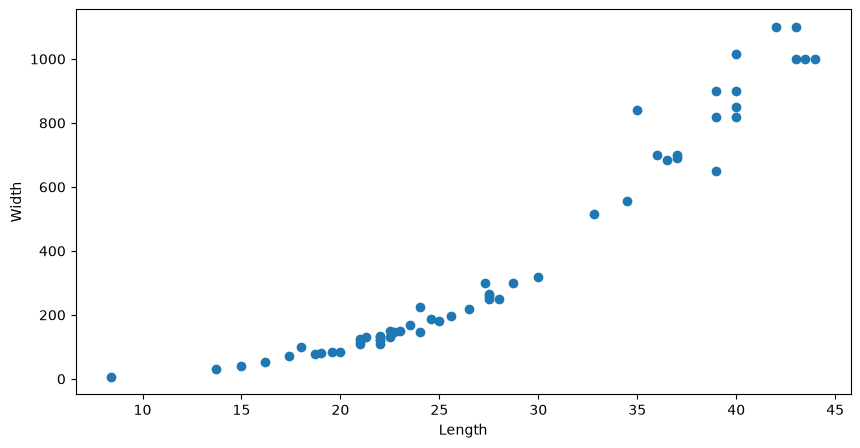

In [5]:
plt.figure(figsize=(10, 5))
plt.scatter(fish_length, fish_weight)
plt.xlabel('Length')
plt.ylabel('Width')
plt.show()

#### Train Set과 Test Set의 분리

In [ ]:
from sklearn.model_selection import train_test_split

In [7]:
train_input, test_input, train_target, test_target = \
    train_test_split(
        fish_length,
        fish_weight,
        random_state=42
    )

분류 문제가 아니기 때문에 stratify는 사용하지 X

In [8]:
#  분리된 결과 확인
print(train_input.shape)
print(test_input.shape)

(42,)
(14,)


In [9]:
train_input

array([19.6, 22. , 18.7, 17.4, 36. , 25. , 40. , 39. , 43. , 22. , 20. ,
       22. , 24. , 27.5, 43. , 40. , 24. , 21. , 27.5, 40. , 32.8, 26.5,
       36.5, 13.7, 22.7, 15. , 37. , 35. , 28.7, 23.5, 39. , 21. , 23. ,
       22. , 44. , 22.5, 19. , 37. , 22. , 25.6, 42. , 34.5])

In [10]:
# 1열로 구성된 배열로 재구성
train_input = train_input.reshape(-1, 1)

In [11]:
train_input

array([[19.6],
       [22. ],
       [18.7],
       [17.4],
       [36. ],
       [25. ],
       [40. ],
       [39. ],
       [43. ],
       [22. ],
       [20. ],
       [22. ],
       [24. ],
       [27.5],
       [43. ],
       [40. ],
       [24. ],
       [21. ],
       [27.5],
       [40. ],
       [32.8],
       [26.5],
       [36.5],
       [13.7],
       [22.7],
       [15. ],
       [37. ],
       [35. ],
       [28.7],
       [23.5],
       [39. ],
       [21. ],
       [23. ],
       [22. ],
       [44. ],
       [22.5],
       [19. ],
       [37. ],
       [22. ],
       [25.6],
       [42. ],
       [34.5]])

In [12]:
test_input = test_input.reshape(-1, 1)

In [13]:
test_input

array([[ 8.4],
       [18. ],
       [27.5],
       [21.3],
       [22.5],
       [40. ],
       [30. ],
       [24.6],
       [39. ],
       [21. ],
       [43.5],
       [16.2],
       [28. ],
       [27.3]])

In [14]:
print(train_input.shape, test_input.shape)

(42, 1) (14, 1)


#### 회귀 모델 사용

In [15]:
from sklearn.neighbors import KNeighborsRegressor

In [17]:
knr = KNeighborsRegressor(n_neighbors=5)
knr.fit(train_input, train_target);

In [19]:
print(knr.score(train_input, train_target))
print(knr.score(test_input, test_target))

0.9698823289099254
0.992809406101064


#### 회귀모델은 분류모델처럼 예측값과 정답값을 비교할 수 없음

### 결정계수 : 평균절대값오차 ( MAE : Mean Absolute Error )

In [20]:
from sklearn.metrics import mean_absolute_error

In [21]:
# 테스트 세트에 대한 예측
pred = knr.predict(test_input)
pred

array([  60. ,   79.6,  248. ,  122. ,  136. ,  847. ,  311.4,  183.4,
        847. ,  113. , 1010. ,   60. ,  248. ,  248. ])

In [22]:
# 테스트 세트에 대한 평균 절대값오차
mae = mean_absolute_error(test_target, pred)
mae

19.157142857142862

#### knn의 Hyper parameter를 조절

In [23]:
# 이웃의 갯수를 3으로 설정
knr.n_neighbors = 3

# 모델을 다시 훈련
knr.fit(train_input, train_target)
print("Train :", knr.score(train_input, train_target))
print("Test :", knr.score(test_input, test_target))

Train : 0.9804899950518966
Test : 0.9746459963987609


In [24]:
# 테스트 세트에 대한 예측
pred = knr.predict(test_input)
mae = mean_absolute_error(test_target, pred)
mae

35.42380952380951

#### 이웃의 갯수 조절로 확인

In [29]:
# x축의 범위
print(fish_length.min())
print(fish_length.max())

8.4
44.0


k => 1
Train Score : 0.9804899950518966
Test Score : 0.9746459963987609
----------------------------------------


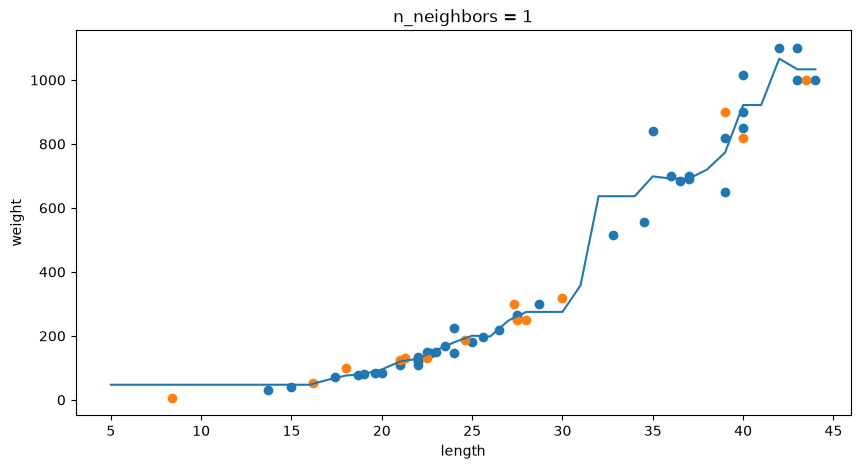

k => 3
Train Score : 0.9804899950518966
Test Score : 0.9746459963987609
----------------------------------------


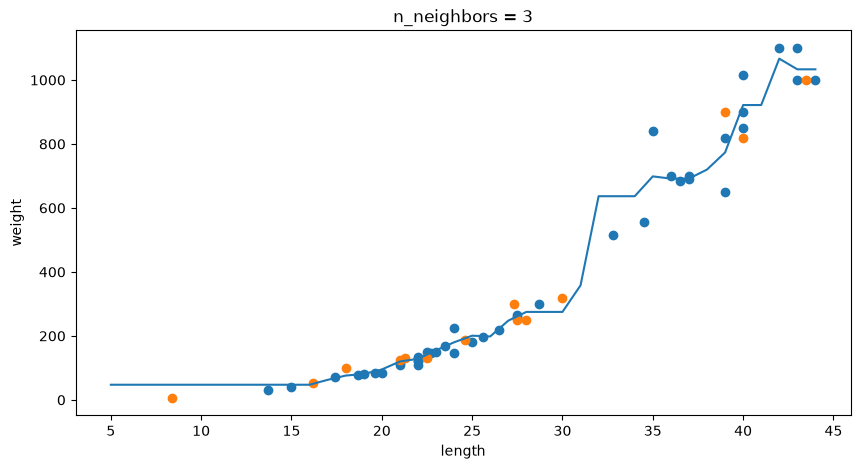

k => 5
Train Score : 0.9804899950518966
Test Score : 0.9746459963987609
----------------------------------------


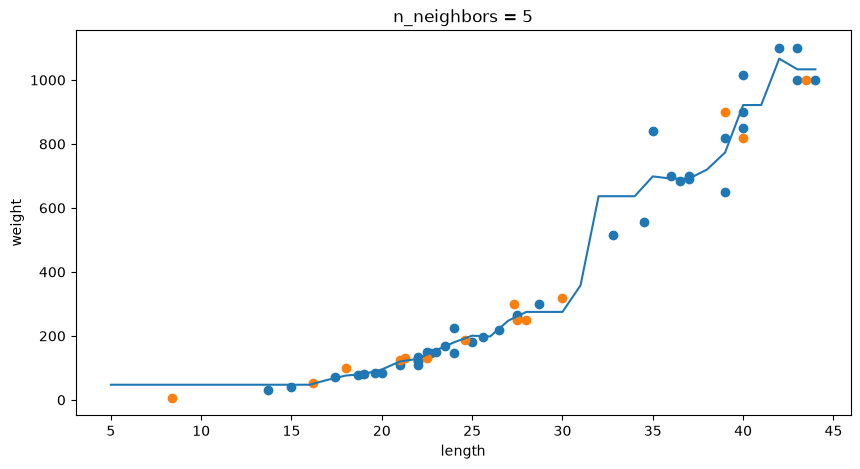

k => 10
Train Score : 0.9804899950518966
Test Score : 0.9746459963987609
----------------------------------------


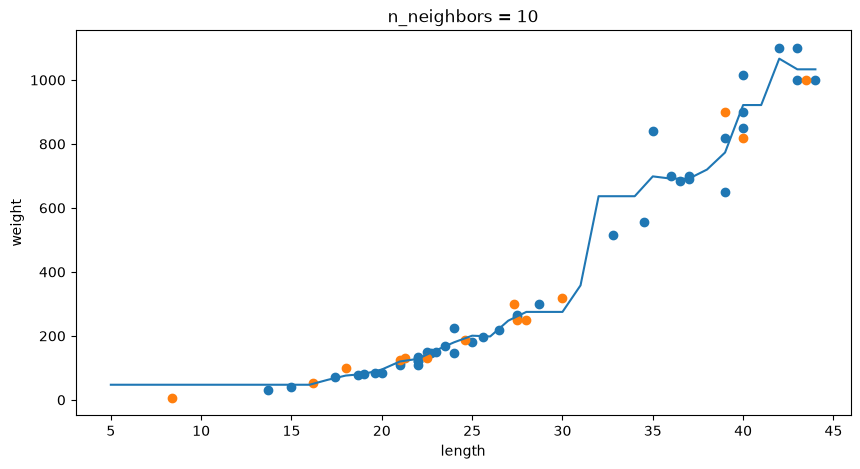

In [36]:
knr = KNeighborsRegressor()

x = np.arange(5, 45).reshape(-1, 1)

for n in [1, 3, 5, 10] :

    knr.n_neighbors = 3
    knr.fit(train_input, train_target)
    print("k =>", n)
    print("Train Score :", knr.score(train_input, train_target))
    print("Test Score :", knr.score(test_input, test_target))
    print("-" * 40)

    # 지정한 범위 x에 대한 예측 구하기
    pred = knr.predict(x)

    # 훈련세트와 검증세트의 예측 결과 그래프 그리기
    plt.figure(figsize=(10, 5))
    plt.scatter(train_input, train_target)
    plt.scatter(test_input, test_target)
    plt.plot(x, pred)
    plt.title(f'n_neighbors = {n}')
    plt.xlabel('length')
    plt.ylabel('weight')
    plt.show()
